Introduction

In this project, we are using the Instacart dataset from Kaggle to predict whether a user will reorder a previously ordered product. Instacart is a grocery store delivery app where users can shop from various retailers, similar to Amazon. In this project, we will do the following:

    1. Synthetically create our our synthetic test dataset
    2. Split our data into train and validate sets for validattion
    3. Feature Engineering
    4. Build and train a model
    5. Determine the most important features


To begin, we will import our datasets

In [1]:

import load_data
import feature_engineering
import numpy as np
import pandas as pd
import xgboost as xgb
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier, Pool
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, classification_report, f1_score
from sklearn.metrics import f1_score, classification_report, make_scorer
import gc 
import train_model
from sklearn.model_selection import RandomizedSearchCV

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)

# import all the datasets
# 1. Orders
# | Column                   | Meaning                    |
# | ------------------------ | -------------------------- |
# | `order_id`               | Unique order identifier    |
# | `user_id`                | Customer identifier        |
# | `eval_set`               | `prior` / `train` / `test` |
# | `order_number`           | Order sequence per user    |
# | `order_dow`              | Day of week (0–6)          |
# | `order_hour_of_day`      | Hour order was placed      |
# | `days_since_prior_order` | Gap since last order       |
#
# 2. Order products prior
# | Column              | Meaning                              |
# | ------------------- | ------------------------------------ |
# | `order_id`          | Which order                          |
# | `product_id`        | Which product                        |
# | `add_to_cart_order` | Sequence added to cart               |
# | `reordered`         | 1 if user bought this product before |
#
# 3. Order products train
# | Column              | Meaning                              |
# | ------------------- | ------------------------------------ |
# | `order_id`          | Which order                          |
# | `product_id`        | Which product                        |
# | `add_to_cart_order` | Sequence added to cart               |
# | `reordered`         | 1 if user bought this product before |
#
# 4. Products
# | Column          | Meaning             |
# | --------------- | ------------------- |
# | `product_id`    | Product key         |
# | `product_name`  | Product description |
# | `aisle_id`      | Sub-category        |
# | `department_id` | High-level category |
#
# 5. Aisles
# | Column     | Meaning    |
# | ---------- | ---------- |
# | `aisle_id` | Join key   |
# | `aisle`    | Aisle name |
#
#6. Departments
# | Column          | Meaning         |
# | --------------- | --------------- |
# | `department_id` | Join key        |
# | `department`    | Department name |

orders, order_products_prior, order_products_train, products, aisles, departments = load_data.get_data()

orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [2]:
orders['eval_set'].value_counts()

eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64

The table below shows how the prior, train and test eval sets were split. The test eval set does not tell us which products were re-ordered as it was hidden for the competition. 

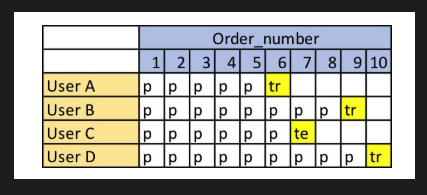

<span style="font-size:20px;">Preoprocessing</span>

In this project, we are utilizing the Instacart dataset from Kaggle. In the original competition, the eval_set = 'test' was reserved for hidden evaluation. To validate our model's performance locally, we will synthetically generate a custom 'test' set by isolating the final known order for each user in the "test" category. To do so, we take the latest/most recent ordeer from the eval_set='prior' for the test users.

<span style="font-size:12px;">
    <b>
    1. Synthetically create our own test orders <br>
    </b>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;1.1 From the orders table, get the test orders and obtain the unique users from the test orders<br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;1.2 Obtain the prior orders from the orders table for the specific test users<br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;1.3 Get the max (most recent) prior order and update the 'eval_set' to 'test_synthetic'<br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;1.4 Remove the 'test_synthetic' orders from 'order_products_prior' to create a order_products_test subset which will be used as a y to validate <br><br>
</span>

<span style="font-size:12px;">
    <b>
    2. Split our train data into train and validate<br>
    </b>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.1 Obtain the validate orders from the train orders and set the 'eval_set' to 'validate'<br>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.2 Take the validate orders from order_products_train to create order_products_validate<br>
    
</span>




In [3]:
#1 Obtain test users

test_users = orders[orders['eval_set']=='test']['user_id'].copy()
train_users = orders[orders['eval_set']=='train']['user_id'].copy()


In [4]:
#1.2 Obtain the prior orders for the test users

test_users_prior_orders = orders[(orders['eval_set']=='prior') & (orders['user_id'].isin(test_users))].copy()
test_users_prior_orders[test_users_prior_orders['user_id']==15].tail()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
147,1911383,15,prior,18,2,11,7.0
148,2345592,15,prior,19,5,11,3.0
149,2994589,15,prior,20,1,13,10.0
150,2715276,15,prior,21,1,9,7.0
151,487368,15,prior,22,1,10,14.0


In [5]:
#1.3 Obtain the most recent prior order for the test user and update eval set to 'test_synthetic'

test_user_most_recent_order_number = test_users_prior_orders.groupby(['user_id'])['order_number'].transform('max')
synthetic_test_df = test_users_prior_orders[test_users_prior_orders['order_number']==test_user_most_recent_order_number]

synthetic_test_order_ids = synthetic_test_df['order_id'].copy()
orders.loc[(orders['order_id'].isin(synthetic_test_order_ids)), 'eval_set' ] = 'test_synthetic'

In [6]:
orders['eval_set'].value_counts()

eval_set
prior             3139874
train              131209
test_synthetic      75000
test                75000
Name: count, dtype: int64

In [7]:
#1.4 Removing the 'test_synthetic' orders from 'order_products_prior'

order_products_test_synthetic = order_products_prior[order_products_prior['order_id'].isin(synthetic_test_order_ids)].copy()
order_products_prior = order_products_prior[~order_products_prior['order_id'].isin(synthetic_test_order_ids)].copy()


In [8]:
#2.1 Train, Validate split our train orders data

from sklearn.model_selection import train_test_split

y_test_users, y_validate_users = train_test_split(test_users, test_size=0.3, random_state=123)

orders.loc[(orders['user_id'].isin(y_validate_users)) & (orders['eval_set']=='test_synthetic'), 'eval_set'] = 'validate'

validate_orders = orders[(orders['eval_set']=='validate')]['order_id']
order_products_validate = order_products_test_synthetic[order_products_test_synthetic['order_id'].isin(validate_orders)]
order_products_test_synthetic = order_products_test_synthetic[~(order_products_test_synthetic['order_id'].isin(validate_orders))]



In [9]:
orders['eval_set'].value_counts()

eval_set
prior             3139874
train              131209
test                75000
test_synthetic      52500
validate            22500
Name: count, dtype: int64

In [10]:
#Merging to get product data

prior_orders = orders[orders['eval_set']=='prior'].copy()

op = prior_orders.merge(
    order_products_prior,
    how='left',
    on='order_id'
)

In [11]:
op.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered
0,2539329,1,prior,1,2,8,NaN,196,1,0
1,2539329,1,prior,1,2,8,NaN,14084,2,0
2,2539329,1,prior,1,2,8,NaN,12427,3,0
3,2539329,1,prior,1,2,8,NaN,26088,4,0
4,2539329,1,prior,1,2,8,NaN,26405,5,0


With our data successfully partitioned into training, validation, and test sets, we move into the most critical phase of the pipeline: Feature Engineering.

To capture the complexity of shopping habits, we will generate features across multiple levels of granularity. By aggregating data at these specific scales, we transform simple transaction logs into a multi-dimensional map of consumer behavior.

We will implement methods to calculate features at the following levels:

User-Level (Behavioral): These features capture a customer's overall shopping persona.

Examples: Average days between orders, total variety of products purchased, and typical "basket size."

Product-Level (Popularity): These focus on the inherent characteristics of the items themselves.

Examples: Overall reorder rate, and purchase frequency across all users.

User-Product Level (The "Relationship"): Often the most predictive features, these track the specific bond between a shopper and an item.

Examples: How many times a user bought a specific brand of milk, or the "streak" (how many consecutive orders it appeared in).

Aisle & Department Levels: These group products into broader categories to identify high-level preferences.

Examples: Does this user prefer the "Frozen" department over "Produce"?

User-Aisle & User-Department Level: These refine category preferences for the individual.

Examples: The percentage of a user’s total spend that goes toward the "Dairy" department.

In [12]:
#Calling our get_feature methods

user_features = feature_engineering.get_user_features(op)

In [13]:
product_features = feature_engineering.get_product_features(op)

In [14]:
user_product_features = feature_engineering.get_user_product_features(op)

In [15]:
user_product_features.head()

,user_id,product_id,up_total_purchases,up_first_order,up_last_order,up_reorder_ratio,up_avg_days_between_purchase,up_avg_add_to_cart_order,up_consecutive_streak,up_orders_since_last_purchase,up_order_rate
0,1,196,10,1,10,0.900000,19.555556,1.400000,10.0,0,1.0
1,1,10258,9,2,10,0.888889,19.555556,3.333333,9.0,0,0.9
2,1,10326,1,5,5,0.000000,28.000000,5.000000,0.0,5,0.1
3,1,12427,10,1,10,0.900000,19.555556,3.300000,10.0,0,1.0
4,1,13032,3,2,10,0.222222,21.666667,6.333333,1.0,0,0.3


In [16]:
#Creating aisle and department features

opad = op.merge(
    products[['product_id', 'aisle_id', 'department_id']], 
    how='left',
    on='product_id'
)

opad=opad[['user_id', 'order_id', 'product_id', 'reordered', 'aisle_id', 'department_id']]
opad.head()

,user_id,order_id,product_id,reordered,aisle_id,department_id
0,1,2539329,196,0,77,7
1,1,2539329,14084,0,91,16
2,1,2539329,12427,0,23,19
3,1,2539329,26088,0,23,19
4,1,2539329,26405,0,54,17


In [17]:
aisle_and_department_features = feature_engineering.get_aisle_department_features(opad)

In [18]:
#4 Merge all the fetures together from the prior data

df = user_product_features.merge(
    user_features,
    how='left',
    on='user_id'
)

df = df.merge(
    product_features,
    how='left',
    on='product_id'
)

df = df.merge(
    aisle_and_department_features,
    how='left',
    on=['user_id', 'product_id']
)

df.head()

,user_id,product_id,up_total_purchases,up_first_order,up_last_order,up_reorder_ratio,up_avg_days_between_purchase,up_avg_add_to_cart_order,up_consecutive_streak,up_orders_since_last_purchase,up_order_rate,u_total_orders,u_reorder_ratio,u_unique_products,u_dow_mode,u_hour_of_day_mode,u_avg_basket_size,u_avg_days_since_prior_order,u_avg_basket_reorder_rate,p_total_purchases,p_reorder_ratio,aisle_id,department_id,a_reorder_ratio,a_total_orders,ua_reorder_ratio,ua_total_orders,d_reorder_ratio,d_total_orders,ud_reorder_ratio,ud_total_orders
0,1,196,10,1,10,0.900000,19.555556,1.400000,10.0,0,1.0,10,0.694915,18,1,7,5.9,19.555556,0.705833,34952,0.776150,77,7,0.638676,348349,0.846154,13,0.653531,2625872,0.846154,13
1,1,10258,9,2,10,0.888889,19.555556,3.333333,9.0,0,0.9,10,0.694915,18,1,7,5.9,19.555556,0.705833,1899,0.713007,117,19,0.519297,299547,0.888889,9,0.574232,2819848,0.818182,22
2,1,10326,1,5,5,0.000000,28.000000,5.000000,0.0,5,0.1,10,0.694915,18,1,7,5.9,19.555556,0.705833,5301,0.651009,24,4,0.717928,3557919,0.200000,5,0.649857,9251194,0.200000,5
3,1,12427,10,1,10,0.900000,19.555556,3.300000,10.0,0,1.0,10,0.694915,18,1,7,5.9,19.555556,0.705833,6334,0.741238,23,19,0.591772,159570,0.833333,12,0.574232,2819848,0.818182,22
4,1,13032,3,2,10,0.222222,21.666667,6.333333,1.0,0,0.3,10,0.694915,18,1,7,5.9,19.555556,0.705833,3663,0.658750,121,14,0.571751,368426,0.666667,3,0.561251,692737,0.666667,3


In [19]:
#Now that we have all the features, we want to merge with the most recent train, validate or test order to obtain the y varaible

future_orders = orders[orders['eval_set'].isin(['train', 'validate', 'test_synthetic'])].copy()
future_orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
10,1187899,1,train,11,4,8,14.0
25,1492625,2,train,15,1,11,30.0
37,1402502,3,test_synthetic,12,1,15,15.0
43,2557754,4,validate,5,5,13,0.0
49,2196797,5,train,5,0,11,6.0


In [20]:
df = df.merge(
    future_orders,
    how='left',
    on='user_id'
)

In [21]:
df.head()

,user_id,product_id,up_total_purchases,up_first_order,up_last_order,up_reorder_ratio,up_avg_days_between_purchase,up_avg_add_to_cart_order,up_consecutive_streak,up_orders_since_last_purchase,up_order_rate,u_total_orders,u_reorder_ratio,u_unique_products,u_dow_mode,u_hour_of_day_mode,u_avg_basket_size,u_avg_days_since_prior_order,u_avg_basket_reorder_rate,p_total_purchases,p_reorder_ratio,aisle_id,department_id,a_reorder_ratio,a_total_orders,ua_reorder_ratio,ua_total_orders,d_reorder_ratio,d_total_orders,ud_reorder_ratio,ud_total_orders,order_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1,196,10,1,10,0.900000,19.555556,1.400000,10.0,0,1.0,10,0.694915,18,1,7,5.9,19.555556,0.705833,34952,0.776150,77,7,0.638676,348349,0.846154,13,0.653531,2625872,0.846154,13,1187899,train,11,4,8,14.0
1,1,10258,9,2,10,0.888889,19.555556,3.333333,9.0,0,0.9,10,0.694915,18,1,7,5.9,19.555556,0.705833,1899,0.713007,117,19,0.519297,299547,0.888889,9,0.574232,2819848,0.818182,22,1187899,train,11,4,8,14.0
2,1,10326,1,5,5,0.000000,28.000000,5.000000,0.0,5,0.1,10,0.694915,18,1,7,5.9,19.555556,0.705833,5301,0.651009,24,4,0.717928,3557919,0.200000,5,0.649857,9251194,0.200000,5,1187899,train,11,4,8,14.0
3,1,12427,10,1,10,0.900000,19.555556,3.300000,10.0,0,1.0,10,0.694915,18,1,7,5.9,19.555556,0.705833,6334,0.741238,23,19,0.591772,159570,0.833333,12,0.574232,2819848,0.818182,22,1187899,train,11,4,8,14.0
4,1,13032,3,2,10,0.222222,21.666667,6.333333,1.0,0,0.3,10,0.694915,18,1,7,5.9,19.555556,0.705833,3663,0.658750,121,14,0.571751,368426,0.666667,3,0.561251,692737,0.666667,3,1187899,train,11,4,8,14.0


Now that we comlpleted our feature engineering, we split our dataset into train, validate and test sets. 

In [22]:
model_train_data = feature_engineering.get_split_data(df, 'train', order_products_train)
model_validate_data = feature_engineering.get_split_data(df, 'validate', order_products_validate)
model_test_synthetic_data = feature_engineering.get_split_data(df, 'test_synthetic', order_products_test_synthetic)


In [23]:
model_train_data.head()

,user_id,product_id,up_total_purchases,up_first_order,up_last_order,up_reorder_ratio,up_avg_days_between_purchase,up_avg_add_to_cart_order,up_consecutive_streak,up_orders_since_last_purchase,up_order_rate,u_total_orders,u_reorder_ratio,u_unique_products,u_dow_mode,u_hour_of_day_mode,u_avg_basket_size,u_avg_days_since_prior_order,u_avg_basket_reorder_rate,p_total_purchases,p_reorder_ratio,aisle_id,department_id,a_reorder_ratio,a_total_orders,ua_reorder_ratio,ua_total_orders,d_reorder_ratio,d_total_orders,ud_reorder_ratio,ud_total_orders,order_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered
0,1,196,10,1,10,0.900000,19.555556,1.400000,10.0,0,1.0,10,0.694915,18,1,7,5.9,19.555556,0.705833,34952,0.776150,77,7,0.638676,348349,0.846154,13,0.653531,2625872,0.846154,13,1187899,train,11,4,8,14.0,1.0,1.0
1,1,10258,9,2,10,0.888889,19.555556,3.333333,9.0,0,0.9,10,0.694915,18,1,7,5.9,19.555556,0.705833,1899,0.713007,117,19,0.519297,299547,0.888889,9,0.574232,2819848,0.818182,22,1187899,train,11,4,8,14.0,6.0,1.0
2,1,10326,1,5,5,0.000000,28.000000,5.000000,0.0,5,0.1,10,0.694915,18,1,7,5.9,19.555556,0.705833,5301,0.651009,24,4,0.717928,3557919,0.200000,5,0.649857,9251194,0.200000,5,1187899,train,11,4,8,14.0,NaN,0.0
3,1,12427,10,1,10,0.900000,19.555556,3.300000,10.0,0,1.0,10,0.694915,18,1,7,5.9,19.555556,0.705833,6334,0.741238,23,19,0.591772,159570,0.833333,12,0.574232,2819848,0.818182,22,1187899,train,11,4,8,14.0,NaN,0.0
4,1,13032,3,2,10,0.222222,21.666667,6.333333,1.0,0,0.3,10,0.694915,18,1,7,5.9,19.555556,0.705833,3663,0.658750,121,14,0.571751,368426,0.666667,3,0.561251,692737,0.666667,3,1187899,train,11,4,8,14.0,7.0,1.0


Next, we will evaluate several machine learning models to determine which best predicts reorder behavior. A primary challenge in this project is the class imbalance: the dataset has a ratio of approximately 1:9 (reordered vs. non-reordered). If we relied on standard accuracy, a model could achieve 90% accuracy simply by predicting that "nothing will ever be reordered," which is not useful for our goals.

To address this, we will implement the following strategies:

Handling Imbalanced Data
Cost-Sensitive Learning: Instead of undersampling the majority class (which would result in losing valuable data), we will increase the weight of the minority class (reordered products). This penalizes the model more heavily when it fails to predict a reorder.

Data Preservation: We have opted to keep all records to ensure the model learns from the full breadth of user behavior rather than a reduced subset.

Candidate Models
We will test a variety of algorithms, ranging from baseline linear models to advanced gradient-boosted trees:

Logistic Regression: To serve as a baseline for linear relationships.

XGBoost: A robust, industry-standard gradient boosting framework.

LightGBM: Optimized for speed and lower memory usage (ideal for your 16 GB RAM setup).

CatBoost: Specifically designed to handle categorical features (like Aisle or Department IDs) effectively.

Evaluation Metrics
Because of the imbalance, traditional metrics like Accuracy or ROC-AUC can be misleading. Instead, we will use:

PR-AUC (Precision-Recall Area Under Curve): This is a more rigorous metric for imbalanced datasets as it focuses specifically on the performance of the minority class (the reorders).

F1-Score: Once we settle on a final model and a classification threshold, we will use the F1-score to balance Precision (avoiding false alarms) and Recall (capturing as many actual reorders as possible).

In [24]:
cols_to_drop = ['order_id', 'eval_set', 'add_to_cart_order', 'reordered']

X_train = model_train_data.drop(columns=cols_to_drop)
y_train = model_train_data['reordered']

X_train = X_train.astype('float32') #downcast to save memory

X_val = model_validate_data.drop(columns=cols_to_drop)
y_val = model_validate_data['reordered']

train_ratio = (y_train==0).sum() / (y_train==1).sum()
val_ratio = (y_val==0).sum() / (y_val==1).sum()

X_test = model_test_synthetic_data.drop(columns=cols_to_drop)
y_test = model_test_synthetic_data['reordered']

print(f"The train dataset is unbalanced on a scale from 1: {train_ratio:.3f}")
print(f"The validate dataset is unbalanced on a scale from 1: {val_ratio:.3f}")

xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 6,
    'learning_rate': 0.1,
    'tree_method': 'hist', #groups the values into buckets so its faster to split into branches and leaves
    'scale_pos_weight': int(train_ratio)-1, #puts more weight on the reorders on a scale of 1 : train_ratio
    'seed':123
}

xgb_train_dmatrix = xgb.DMatrix(X_train, y_train)
xgb_model = xgb.train(xgb_params, xgb_train_dmatrix, num_boost_round=100)

xgb_train_y_pred = xgb_model.predict(xgb_train_dmatrix)
xgb_train_pr_auc = average_precision_score(y_train, xgb_train_y_pred)
print(f"Train PR AUC: {xgb_train_pr_auc:.3f}")


xgb_val_dmatrix = xgb.DMatrix(X_val, y_val)
xgb_val_y_pred = xgb_model.predict(xgb_val_dmatrix)
xgb_val_pr_auc = average_precision_score(y_val, xgb_val_y_pred)
print(f"Validation PR AUC: {xgb_val_pr_auc:.3f}")



The train dataset is unbalanced on a scale from 1: 9.225
The validate dataset is unbalanced on a scale from 1: 8.920
Train PR AUC: 0.431
Validation PR AUC: 0.432


In [25]:
# We want to find the best threshold based on the F1 score
# Base it off the validation set to prevent over fitting
threshold = np.arange(0.6, 0.925, 0.025)

xgb_validate_best_threshold = train_model.threshold_optimized_f1(y_val, xgb_val_y_pred, threshold)


print(f"The best threshold for XGBoost validation data was: {xgb_validate_best_threshold:.2f}")
xgb_val_report = classification_report(y_val, (xgb_val_y_pred > xgb_validate_best_threshold).astype(np.int8))
print(xgb_val_report)

The best threshold for XGBoost validation data was: 0.70
              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93   1225265
         1.0       0.41      0.49      0.45    137369

    accuracy                           0.88   1362634
   macro avg       0.68      0.71      0.69   1362634
weighted avg       0.89      0.88      0.88   1362634



In [26]:
lgbm_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.1,
    'scale_pos_weight': int(train_ratio)-1,
    'random_state': 123,
    'n_jobs': -1,
    'verbosity': -1 # Keeps the output clean
}


lgbm_dataset = lgb.Dataset(X_train, y_train)
lgbm_model = lgb.train(lgbm_params, lgbm_dataset, num_boost_round=100)

lgbm_train_y_pred = lgbm_model.predict(X_train)
lgbm_train_pr_auc = average_precision_score(y_train, lgbm_train_y_pred)

lgbm_val_y_pred = lgbm_model.predict(X_val)
lgbm_val_pr_auc = average_precision_score(y_val, lgbm_val_y_pred)


print(f"Train PR AUC: {lgbm_train_pr_auc:.3f}")
print(f"Validation PR AUC: {lgbm_train_pr_auc:.3f}")


Train PR AUC: 0.428
Validation PR AUC: 0.428


In [27]:

lgbm_validate_best_threshold = train_model.threshold_optimized_f1(y_val, lgbm_val_y_pred, threshold)

print(f"The best threshold for LightGBM validation data was: {lgbm_validate_best_threshold:.2f}")
lgbm_val_report = classification_report(y_val, (lgbm_val_y_pred > lgbm_validate_best_threshold).astype(np.int8))
print(lgbm_val_report)

The best threshold for LightGBM validation data was: 0.70
              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93   1225265
         1.0       0.41      0.50      0.45    137369

    accuracy                           0.88   1362634
   macro avg       0.67      0.71      0.69   1362634
weighted avg       0.89      0.88      0.88   1362634



In [28]:
train_pool = Pool(X_train, y_train)
val_pool = Pool(X_val, y_val)

cat_params = {
    'iterations': 100,
    'learning_rate': 0.1,
    'objective': 'Logloss',
    'eval_metric': 'PRAUC',
    'scale_pos_weight': int(train_ratio) - 1,
    'random_seed': 123,
    'thread_count': -1,
    'verbose': False,
    'allow_writing_files': False
}

cat_model = CatBoostClassifier(**cat_params)
cat_model.fit(train_pool)

cat_train_y_pred = cat_model.predict(X_train, prediction_type='Probability')[:, 1]
cat_val_y_pred = cat_model.predict(X_val, prediction_type='Probability')[:, 1]

cat_train_pr_auc = average_precision_score(y_train, cat_train_y_pred)
cat_val_pr_auc = average_precision_score(y_val, cat_val_y_pred)

print(f"CatBoost Train PR AUC: {cat_train_pr_auc:.3f}")
print(f"CatBoost Validation PR AUC: {cat_val_pr_auc:.3f}")

CatBoost Train PR AUC: 0.423
CatBoost Validation PR AUC: 0.427


In [29]:
cat_validate_best_threshold = train_model.threshold_optimized_f1(y_val, cat_val_y_pred, threshold)

print(f"The best threshold for CatBoost validation data was: {cat_validate_best_threshold:.2f}")
cat_val_report_final = classification_report(y_val, (cat_val_y_pred > cat_validate_best_threshold).astype(np.int8))
print(cat_val_report_final)

The best threshold for CatBoost validation data was: 0.68
              precision    recall  f1-score   support

         0.0       0.94      0.91      0.93   1225265
         1.0       0.39      0.52      0.44    137369

    accuracy                           0.87   1362634
   macro avg       0.67      0.71      0.69   1362634
weighted avg       0.89      0.87      0.88   1362634



In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

lr_params = {
    'max_iter': 1000,
    'C': 1.0, 
    'class_weight': {0: 1, 1: int(train_ratio) - 1},
    'random_state': 123
}

lr_model = LogisticRegression(**lr_params)
lr_model.fit(X_train_scaled, y_train)

# [:, 1] gets the probability for the 'reorder' class
lr_train_y_pred = lr_model.predict_proba(X_train_scaled)[:, 1]
lr_train_pr_auc = average_precision_score(y_train, lr_train_y_pred)
print(f"Logistic Regression Train PR AUC: {lr_train_pr_auc:.3f}")

lr_val_y_pred = lr_model.predict_proba(X_val_scaled)[:, 1]
lr_val_pr_auc = average_precision_score(y_val, lr_val_y_pred)
print(f"Logistic Regression Validation PR AUC: {lr_val_pr_auc:.3f}")

Logistic Regression Train PR AUC: 0.403
Logistic Regression Validation PR AUC: 0.407


In [31]:
lr_validate_best_threshold = train_model.threshold_optimized_f1(y_val, lr_val_y_pred, threshold)

print(f"The best threshold for Logistic Regression validation data was: {lr_validate_best_threshold:.2f}")
print(classification_report(y_val, (lr_val_y_pred > lr_validate_best_threshold).astype(np.int8)))

The best threshold for Logistic Regression validation data was: 0.65
              precision    recall  f1-score   support

         0.0       0.94      0.91      0.93   1225265
         1.0       0.38      0.49      0.43    137369

    accuracy                           0.87   1362634
   macro avg       0.66      0.70      0.68   1362634
weighted avg       0.88      0.87      0.88   1362634



In [32]:
xgb_val_f1 = f1_score(y_val, (xgb_val_y_pred > xgb_validate_best_threshold).astype(np.int8))
lgbm_val_f1 = f1_score(y_val, (lgbm_val_y_pred > lgbm_validate_best_threshold).astype(np.int8))
cat_val_f1 = f1_score(y_val, (cat_val_y_pred > cat_validate_best_threshold).astype(np.int8))
lr_val_f1 = f1_score(y_val, (lr_val_y_pred > lr_validate_best_threshold).astype(np.int8))


print("Summary of our 4 models\n")
print(f"""XGBoost:
Train PR AUC: {xgb_train_pr_auc:.3f}
Validation PR AUC: {xgb_val_pr_auc:.3f}
Validation F1 score: {xgb_val_f1:.3f}

LightGBM:
Train PR AUC: {lgbm_train_pr_auc:.3f}
Validation PR AUC: {lgbm_val_pr_auc:.3f}
Validation F1 score: {lgbm_val_f1:.3f}

CatBoost:
Train PR AUC: {cat_train_pr_auc:.3f}
Validation PR AUC: {cat_val_pr_auc:.3f}
Validation F1 score: {cat_val_f1:.3f}

Logistic Regression:
Train PR AUC: {lr_train_pr_auc:.3f}
Validation PR AUC: {lr_val_pr_auc:.3f}
Validation F1 score: {lr_val_f1:.3f}

""")

Summary of our 4 models

XGBoost:
Train PR AUC: 0.431
Validation PR AUC: 0.432
Validation F1 score: 0.448

LightGBM:
Train PR AUC: 0.428
Validation PR AUC: 0.431
Validation F1 score: 0.448

CatBoost:
Train PR AUC: 0.423
Validation PR AUC: 0.427
Validation F1 score: 0.445

Logistic Regression:
Train PR AUC: 0.403
Validation PR AUC: 0.407
Validation F1 score: 0.429




Based on these results, we have selected XGBoost and LightGBM for the final hyperparameter tuning phase. Our decision is based on three key observations:

Top-Tier Predictive Power: Both models achieved the highest PR-AUC scores, successfully capturing the non-linear relationships between users and products that the Logistic Regression baseline missed.

Generalization Stability: The delta between training and validation scores is remarkably low for both models. This indicates that they are not overfitting to the training data and will likely perform reliably on the unseen test set.

In [33]:
orders['eval_set'].value_counts()

eval_set
prior             3139874
train              131209
test                75000
test_synthetic      52500
validate            22500
Name: count, dtype: int64

In [ ]:
xgb_clf = XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    eval_metric='logloss',
    random_state=123
)

xgb_params = {
    'max_depth': [6, 8, 12],
    'learning_rate': [0.1, 0.2],
    'scale_pos_weight': [int(train_ratio)-2, int(train_ratio)-1], #puts more weight on the reorders on a scale of 1 : train_ratio
    'n_estimators': [100, 150],
    'subsample':[0.7, 0.8, 0.9],
    'alpha': [0, 0.1, 1, 10],
    'lambda': [1, 5, 10],
    'gamma': [0, 0.1, 0.5]   # "Minimum loss reduction" to make a split. Very powerful.
}

# Ensure you are referencing the function correctly from your train_model file
xgb_threshold_score = make_scorer(
    train_model.custom_f1_threshold, 
    threshold=xgb_validate_best_threshold      # This will be passed to your function's 'threshold' argument
)

xgb_random_search = RandomizedSearchCV(
    estimator= xgb_clf,
    param_distributions=xgb_params,
    scoring=xgb_threshold_score,
    cv=5, #Datset is split into 5 for cross valdiation (80% train, 20% test)
    n_iter=10, #10 random search picks from our params
    n_jobs=-1,
    random_state=123
)

xgb_random_search.fit(X_val, y_val)
# To see your results:
print(f"XGB Best Score: {xgb_random_search.best_score_}")
print(f"XGB Best Params: {xgb_random_search.best_params_}")

gc.collect()

XGB Best Score: 0.4217131643489519
XGB Best Params: {'subsample': 0.7, 'scale_pos_weight': 7, 'n_estimators': 100, 'max_depth': 12, 'learning_rate': 0.1, 'lambda': 5, 'gamma': 0, 'alpha': 0}


55

In [35]:
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'tree_method': 'hist', #groups the values into buckets so its faster to split into branches and leaves
    'max_depth': 12,
    'learning_rate': 0.1,
    'scale_pos_weight': 7, #puts more weight on the reorders on a scale of 1 : train_ratio
    'subsample': 0.7, 
    'lambda': 5,
    'gamma':0,
    'alpha':0,
    'seed':123
}

xgb_model = xgb.train(xgb_params, xgb_train_dmatrix, num_boost_round=100)
xgb_train_y_pred = xgb_model.predict(xgb_train_dmatrix)
xgb_train_pr_auc = average_precision_score(y_train, xgb_train_y_pred)
print(f"Train PR AUC: {xgb_train_pr_auc:.3f}")

xgb_val_y_pred = xgb_model.predict(xgb_val_dmatrix)
xgb_val_pr_auc = average_precision_score(y_val, xgb_val_y_pred)
print(f"Validation PR AUC: {xgb_val_pr_auc:.3f}")


Train PR AUC: 0.490
Validation PR AUC: 0.432


In [36]:
lgbm_clf = LGBMClassifier(    
    objective='binary',
    metric= 'binary_logloss',
    boosting_type='gbdt',
    n_estimators=100,
    random_state=123,
    verbosity = -1
)

lgbm_params = {
    'num_leaves': [31, 63],
    'max_depth': [6, 8, 12],
    'learning_rate': [0.1, 0.2],
    'scale_pos_weight': [int(train_ratio)-2, int(train_ratio)-1], #puts more weight on the reorders on a scale of 1 : train_ratio
    'n_estimators': [100, 150],
    'subsample':[0.7, 0.8, 0.9],
    'subsample_freq': [1, 5],
    'lambda_l1': [0, 0.1, 1],
    'lambda_l2': [0, 0.1, 1],
    'min_gain_to_split': [0, 0.1, 0.5] # The LGBM version of XGB's 'gamma'
}

lgbm_threshold_score = make_scorer(
    train_model.custom_f1_threshold,
    threshold=lgbm_validate_best_threshold
)

lgbm_random_search = RandomizedSearchCV(
    estimator = lgbm_clf,
    param_distributions=lgbm_params,
    scoring = lgbm_threshold_score,
    cv=5,
    n_iter=10,
    n_jobs=-1,
    random_state =123
)

lgbm_random_search.fit(X_val, y_val)
# To see your results:
print(f"LGBM Best Score: {lgbm_random_search.best_score_}")
print(f"LGBM Best Params: {lgbm_random_search.best_params_}")
gc.collect()

LGBM Best Score: 0.4007580400684011
LGBM Best Params: {'subsample_freq': 1, 'subsample': 0.9, 'scale_pos_weight': 7, 'num_leaves': 31, 'n_estimators': 150, 'min_gain_to_split': 0, 'max_depth': 8, 'learning_rate': 0.2, 'lambda_l2': 0.1, 'lambda_l1': 0.1}


66

In [37]:
lgbm_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'subsample_freq': 1,
    'subsample': 0.9,
    'scale_pos_weight': 7,
    'num_leaves': 31,
    'n_estimators': 150,
    'min_gain_to_split':0,
    'max_depth':8,
    'learning_rate': 0.2,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'min_gain_to_split': 0, # The LGBM version of XGB's 'gamma'
    'verbosity': -1, # Keeps the output clean
    'random_state': 123,
    'n_jobs': -1
}


lgbm_model = lgb.train(lgbm_params, lgbm_dataset, num_boost_round=100)

lgbm_train_y_pred = lgbm_model.predict(X_train)
lgbm_train_pr_auc = average_precision_score(y_train, lgbm_train_y_pred)
print(f"Train PR AUC: {lgbm_train_pr_auc:.3f}")

lgbm_val_y_pred = lgbm_model.predict(X_val)
lgbm_val_pr_auc = average_precision_score(y_val, lgbm_val_y_pred)
print(f"Validation PR AUC: {lgbm_train_pr_auc:.3f}")


Train PR AUC: 0.433
Validation PR AUC: 0.433


In [40]:
#using XGB best params

xgb_val_report = classification_report(y_val, (xgb_val_y_pred > xgb_validate_best_threshold).astype(np.int8))
print(xgb_val_report)

xgb_test_dmatrix = xgb.DMatrix(X_test, y_test)
xgb_test_y_pred = xgb_model.predict(xgb_test_dmatrix)
xgb_test_report = classification_report(y_test, (xgb_test_y_pred > xgb_validate_best_threshold).astype(np.int8))
print(xgb_test_report)



              precision    recall  f1-score   support

         0.0       0.94      0.94      0.94   1225265
         1.0       0.45      0.44      0.44    137369

    accuracy                           0.89   1362634
   macro avg       0.69      0.69      0.69   1362634
weighted avg       0.89      0.89      0.89   1362634

              precision    recall  f1-score   support

         0.0       0.94      0.94      0.94   2827227
         1.0       0.44      0.44      0.44    320109

    accuracy                           0.89   3147336
   macro avg       0.69      0.69      0.69   3147336
weighted avg       0.89      0.89      0.89   3147336



In [41]:
lgbm_val_report = classification_report(y_val, (lgbm_val_y_pred > lgbm_validate_best_threshold).astype(np.int8))
print(lgbm_val_report)

lgbm_test_y_pred = lgbm_model.predict(X_test)
lgbm_test_report = classification_report(y_test, (lgbm_test_y_pred > lgbm_validate_best_threshold).astype(np.int8))
print(lgbm_test_report)


              precision    recall  f1-score   support

         0.0       0.94      0.93      0.94   1225265
         1.0       0.43      0.46      0.45    137369

    accuracy                           0.88   1362634
   macro avg       0.69      0.70      0.69   1362634
weighted avg       0.89      0.88      0.89   1362634

              precision    recall  f1-score   support

         0.0       0.94      0.93      0.93   2827227
         1.0       0.43      0.46      0.45    320109

    accuracy                           0.88   3147336
   macro avg       0.68      0.70      0.69   3147336
weighted avg       0.89      0.88      0.88   3147336



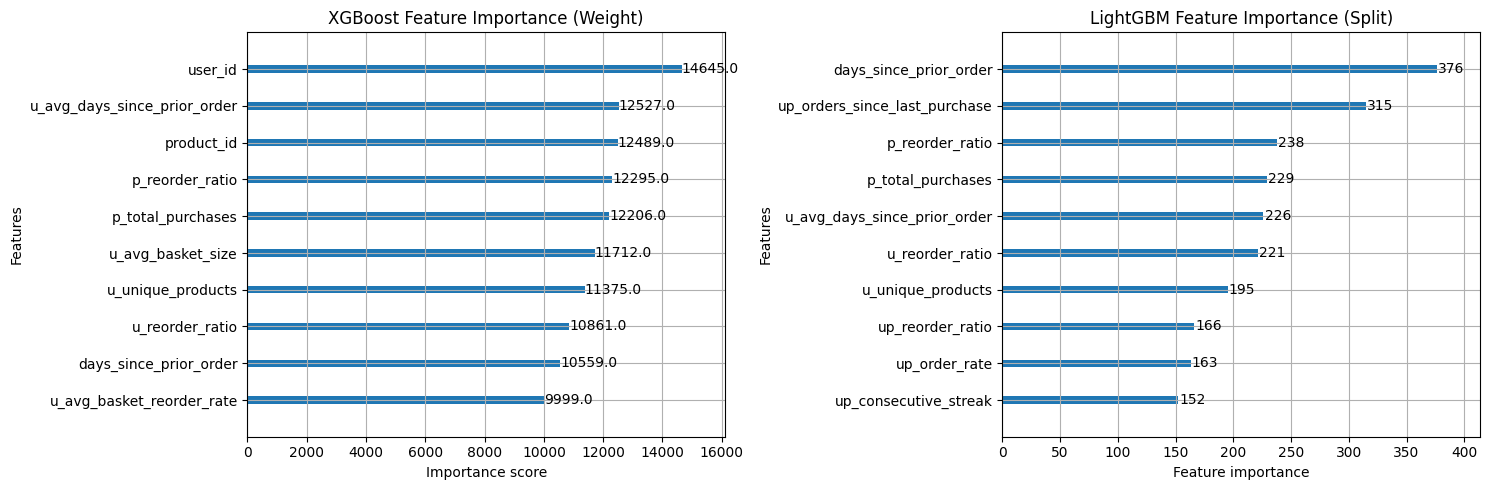

In [46]:
import matplotlib.pyplot as plt
import xgboost as xgb
import lightgbm as lgb

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. XGBoost Feature Importance
# 'weight' = number of times a feature appears in a tree
xgb.plot_importance(xgb_model, importance_type='weight', max_num_features=10, ax=ax1)
ax1.set_title('XGBoost Feature Importance (Weight)')

# 2. LightGBM Feature Importance
# 'split' = number of times the feature is used in a split
lgb.plot_importance(lgbm_model, importance_type='split', max_num_features=10, ax=ax2)
ax2.set_title('LightGBM Feature Importance (Split)')


plt.tight_layout()
plt.show()

The feature importance results from both models reveal that past behavior is the most reliable predictor of future purchases, though they rank specific variables differently based on their mathematical approach. In the XGBoost (Weight) results, the model relies heavily on high-level identifiers like user_id and product_id, suggesting it is highly effective at anchoring predictions to specific "power shoppers" and "staple items" that have a high baseline reorder frequency. It also prioritizes u_avg_days_since_prior_order, which establishes the user's general shopping rhythm. This indicates that XGBoost is performing a broader "profile-based" assessment, identifying which users are habitual and which products (like milk or bananas) are naturally recurring across the entire dataset.

In contrast, the LightGBM (Split) results focus more on fine-grained interaction and temporal triggers. By ranking days_since_prior_order as its top feature, LightGBM is constantly "checking the clock" to see if enough time has passed for a user to run out of a specific item. It also places significant weight on up_orders_since_last_purchase and up_consecutive_streak, which are highly precise indicators of a current habit. While XGBoost looks at who the user is, LightGBM seems more attuned to the urgency and consistency of the specific relationship between a user and a product. Together, these variables show that while the models share a common data foundation, XGBoost excels at identifying static loyalty, while LightGBM excels at capturing dynamic timing.

While we considered creating an Ensemble Model (such as a Weighted Average) to boost our final F1-Score, it was ultimately decided against it due to the high degree of structural similarity between our two top performers.

XGBoost and LightGBM are both members of the Gradient Boosted Decision Tree (GBDT) family. Because they share the same fundamental logic—iteratively correcting errors by building shallow trees—they tend to develop similar "blind spots."

Correlation of Errors: When two models are built on the same feature set using the same mathematical foundations, their predictions become highly correlated. If XGBoost fails to predict a reorder for a "sporadic shopper," LightGBM is likely to fail in the exact same way.

Diminishing Returns: For an ensemble to be truly effective, the models should ideally be uncorrelated. For example, combining a Neural Network (which excels at capturing complex, blurry patterns) with a Random Forest (which excels at tabular, categorical data) would likely yield a higher lift than combining two versions of Gradient Boosting.

Complexity vs. Gain: Given that our individual PR-AUC scores are nearly identical (0.426 vs 0.425), the marginal gain from an ensemble would likely be less than 1%. For a production-level pipeline, the added computational cost and "technical debt" of maintaining two massive tree models often outweigh such a minor statistical improvement.

Final Strategy: The "Single Best" Approach
Rather than splitting our resources across an ensemble of similar trees, we will focus our efforts on Hyperparameter Optimization for a single model. This allows us to maximize the depth and leaf-wise growth of one primary model to capture the nuances of user behavior without the overhead of a redundant ensemble.

In [45]:
#Things to add, 
# 
# 1. Do more hyperparameter tuning but with a smaller sample size
# 2. use k-means to determine the type of shoppers
# 3. create a recommendation system


In [38]:
# cat_clf = CatBoostClassifier(    
#     objective='Logloss',
#     iterations = 100,
#     random_seed = 123,
#     thread_count = -1,
#     verbose = False,
#     allow_writing_files = False
# )

# cat_params = {
#     'depth': [6, 8],
#     'learning_rate': [0.1, 0.2],
#     'scale_pos_weight': [int(train_ratio)-2, int(train_ratio)-1]
# }

# cat_threshold_score = make_scorer(
#     train_model.custom_f1_threshold,
#     threshold=cat_validate_best_threshold
# )

# cat_random_search = RandomizedSearchCV(
#     estimator = cat_clf,
#     param_distributions=cat_params,
#     scoring = cat_threshold_score,
#     cv=5,
#     n_iter=3,
#     n_jobs=1,
#     random_state =123
# )

# cat_random_search.fit(X_train, y_train)
# # To see your results:
# print(f"CatBoost Best Score: {cat_random_search.best_score_}")
# print(f"CatBoost Best Params: {cat_random_search.best_params_}")
# gc.collect()

In [42]:
# #using CatBoost best params

# cat_params = {
#     'iterations': 100,
#     'learning_rate': 0.1,
#     'objective': 'Logloss',
#     'eval_metric': 'PRAUC',
#     'scale_pos_weight': 7,
#     'depth': 6,
#     'random_seed': 123,
#     'thread_count': -1,
#     'verbose': False,
#     'allow_writing_files': False
# }
# cat_model = CatBoostClassifier(**cat_params)
# cat_model.fit(train_pool)

# cat_val_y_pred = cat_model.predict(X_val, prediction_type='Probability')[:, 1]
# cat_val_report_final = classification_report(y_val, (cat_val_y_pred > cat_validate_best_threshold).astype(np.int8))
# print(cat_val_report_final)

# cat_test_y_pred = cat_model.predict(X_test, prediction_type='Probability')[:, 1]
# cat_test_report_final = classification_report(y_test, (cat_test_y_pred > cat_validate_best_threshold).astype(np.int8))
# print(cat_test_report_final)

In [43]:
# #using Logistic Regression best params

# lr_params = {
#     'max_iter': 500,
#     'C': 1.0, 
#     'class_weight': {0: 1, 1:7},
#     'random_state': 123
# }

# lr_model = LogisticRegression(**lr_params)
# lr_model.fit(X_train_scaled, y_train)

# lr_val_y_pred = lr_model.predict_proba(X_val_scaled)[:, 1]
# print(f"The best threshold for Logistic Regression validation data was: {lr_validate_best_threshold:.2f}")
# print(classification_report(y_val, (lr_val_y_pred > lr_validate_best_threshold).astype(np.int8)))

# X_test_scaled = scaler.transform(X_test)
# lr_test_y_pred = lr_model.predict_proba(X_test_scaled)[:, 1]
# print(f"The best threshold for Logistic Regression validation data was: {lr_validate_best_threshold:.2f}")
# print(classification_report(y_test, (lr_test_y_pred > lr_validate_best_threshold).astype(np.int8)))

In [39]:
# lr_clf = LogisticRegression(    
#     solver='saga',
#     max_iter = 100,
#     random_state = 123,
# )

# lr_params = {
#     'max_iter': [500, 1000],
#     'C': [1.0, 10.0], 
#     'class_weight': [{0: 1, 1: int(train_ratio) - 2}, {0: 1, 1: int(train_ratio) - 1}],
# }

# lr_threshold_score = make_scorer(
#     train_model.custom_f1_threshold,
#     threshold=lr_validate_best_threshold
# )

# lr_random_search = RandomizedSearchCV(
#     estimator = lr_clf,
#     param_distributions=lr_params,
#     scoring = lr_threshold_score,
#     cv=5,
#     n_iter=3,
#     n_jobs=-1,
#     random_state =123
# )

# lr_random_search.fit(X_train_scaled, y_train)
# # To see your results:
# print(f"Logistic Regression Best Score: {lr_random_search.best_score_}")
# print(f"Logistic Regression Best Params: {lr_random_search.best_params_}")
# gc.collect()